### Import Libraries


In [ ]:
import numpy as np
from matplotlib import rc
import matplotlib.pyplot as plt

In [ ]:
!apt-get install texlive texlive-latex-extra texlive-fonts-recommended dvipng

### Ex1 - The Beverton - Holt Model

In [ ]:
def f(N, R, c):
    """Beverton–Holt map"""
    return (R * N) / (1 + c * N)

In [ ]:
def plot_cobweb(f, R, c, N0, nmax=10):
    """
    Draw cobweb diagram
    """

    N_star = (R - 1) / c if R > 1 else 0
    N_vals = np.linspace(0, max(5, N_star * 1.5), 500)

    N_series = [N0]
    for _ in range(nmax):
        N_series.append(f(N_series[-1], R, c))

    cobweb_x = []
    cobweb_y = []

    cobweb_x.append(N0)
    cobweb_y.append(0)

    cobweb_x.append(N0)
    cobweb_y.append(N0)

    for i in range(len(N_series) - 1):
        Nt = N_series[i]
        Nt1 = N_series[i+1]

        # vertical
        cobweb_x.append(Nt)
        cobweb_y.append(Nt1)

        # horizontal)
        cobweb_x.append(Nt1)
        cobweb_y.append(Nt1)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111)

    # plot y = f(N) và y = N
    ax.plot(N_vals, f(N_vals, R, c), 'k', lw=2, label=r"$f(N)$")
    ax.plot(N_vals, N_vals, 'k--', lw=1.5, label=r"$y=N$")

    # cobweb path
    ax.plot(cobweb_x, cobweb_y, color='blue', lw=1.8, alpha=0.9)

    # mark N*
    if R > 1:
        ax.plot(N_star, N_star, 'ro', label=rf"$N^* = {N_star:.2f}$", markersize=7)
        ax.axvline(N_star, linestyle=":", color="red", alpha=0.6)

    ax.plot(N0, 0, 'go', label=r"$N_0$", markersize=7)

    ax.set_xlabel(r"$N_t$")
    ax.set_ylabel(r"$N_{t+1} = \dfrac{R N_t}{1 + c N_t}$")
    ax.set_title(rf"Cobweb Diagram for Beverton--Holt (R={R}, c={c})")

    ax.grid(alpha=0.4)
    ax.legend(loc='upper left')
    ax.set_aspect("equal")
    ax.set_xlim(0, max(5, N_star * 1.5))
    ax.set_ylim(0, max(5, N_star * 1.5))

    plt.show()

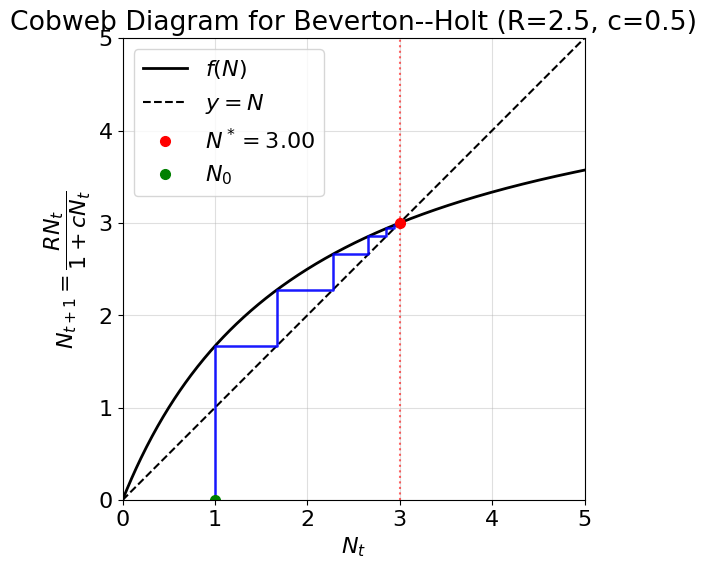

In [ ]:
plot_cobweb(f, R=2.5, c=0.5, N0=1.0)